In [4]:
#Before this
#Use
#pip install sklearn
#pip install imblearn
#pip install pandas
#pip install seaborn
#pip install matplotlib
#pip install nltk
#pip install re
import pandas as pd
df = pd.read_csv('C:/Kabir/College Work/Semester 6/CSD 330/Project/Data Sets/detecting-insults-in-social-commentary/train.csv', encoding='ISO-8859-1');

In [5]:
#Import for regular expressions
import re
#Import for tokenisation, lemmatisation, etc.
import nltk

In [6]:
nltk.download('punkt')
from nltk.tokenize import word_tokenize as wt 

[nltk_data] Downloading package punkt to
[nltk_data]     C:\Users\kabir\AppData\Roaming\nltk_data...
[nltk_data]   Package punkt is already up-to-date!


In [7]:
nltk.download('stopwords')
from nltk.corpus import stopwords

[nltk_data] Downloading package stopwords to
[nltk_data]     C:\Users\kabir\AppData\Roaming\nltk_data...
[nltk_data]   Package stopwords is already up-to-date!


In [8]:
from nltk.stem.porter import PorterStemmer
stemmer = PorterStemmer()
from nltk.stem import WordNetLemmatizer 
lemmatizer = WordNetLemmatizer()

In [9]:
#View dataset schema
df.head()

,Insult,Date,Comment
0,1,20120618192155Z,"""You fuck your dad."""
1,0,20120528192215Z,"""i really don't understand your point.\xa0 It ..."
2,0,NaN,"""A\\xc2\\xa0majority of Canadians can and has ..."
3,0,NaN,"""listen if you dont wanna get married to a man..."
4,0,20120619094753Z,"""C\xe1c b\u1ea1n xu\u1ed1ng \u0111\u01b0\u1edd..."


In [10]:
#Remove irrelevant features
df = df.drop('Date',axis=1)

In [11]:
#Check for null values
import seaborn as sb
import matplotlib
sb.heatmap(df.isnull())

In [12]:
comments = []
for i in range(df.shape[0]):
    comment = df.iloc[i, 1]
    #Regular expression for words with slashes
    slash_all = r'\s*(?:[\w_]*[/\\](?:[\w_]*[/\\])*[\w_]*)'
    #Remove words with slashes
    comment = re.sub(slash_all,' ',comment)
    #Remove special characters except '
    comment = re.sub('[^\'A-Za-z]',' ',comment)
    #Remove extra whitespace
    comment = comment.strip()
    #Change to lower case
    comment = comment.lower()
    #Tokenise
    tokenised_comment = wt(comment)
    #Remove stop words and lemmatise
    comments_processed = []
    for word in tokenised_comment:
        if word not in set(stopwords.words('english')):
            word = lemmatizer.lemmatize(word)
            comments_processed.append(stemmer.stem(word))
    comment_text = " ".join(comments_processed)
    comments.append(comment_text)

In [13]:
df2 = pd.read_csv('C:/Kabir/College Work/Semester 6/CSD 330/Project/Data Sets/detecting-insults-in-social-commentary/test_with_solutions.csv', encoding='ISO-8859-1');

In [14]:
df2.head()

,Insult,Date,Comment,Usage
0,0,NaN,"""THE DRUDGE REPORT\\n\\n\\n\\nYou won't see th...",PublicTest
1,0,20120618222256Z,"""@ian21\xa0""Roger Clemens is the fucking man, ...",PublicTest
2,1,20120618213617Z,"""Agree with Alan you are an extremest idiot. ...",PublicTest
3,0,NaN,"""Really?\\n\\nI see Marc Lamont Hill on variou...",PrivateTest
4,0,20120620003825Z,"""Really suck isn't the word, when many of our ...",PrivateTest


In [15]:
cols_to_drop = ['Date','Usage']
df2 = df2.drop(cols_to_drop,axis=1)

In [16]:
df2.head()

,Insult,Comment
0,0,"""THE DRUDGE REPORT\\n\\n\\n\\nYou won't see th..."
1,0,"""@ian21\xa0""Roger Clemens is the fucking man, ..."
2,1,"""Agree with Alan you are an extremest idiot. ..."
3,0,"""Really?\\n\\nI see Marc Lamont Hill on variou..."
4,0,"""Really suck isn't the word, when many of our ..."


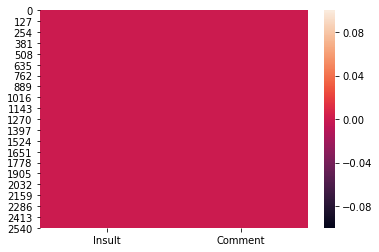

In [17]:
#Check for null values
sb.heatmap(df2.isnull())

In [18]:
comments_test = []
for i in range(df2.shape[0]):
    comment = df2.iloc[i, 1]
    #Regular expression for words with slashes
    slash_all = r'\s*(?:[\w_]*[/\\](?:[\w_]*[/\\])*[\w_]*)'
    #Remove words with slashes
    comment = re.sub(slash_all,' ',comment)
    #Remove special characters except '
    comment = re.sub('[^\'A-Za-z]',' ',comment)
    #Remove extra whitespace
    comment = comment.strip()
    #Change to lower case
    comment = comment.lower()
    #Tokenise
    tokenised_comment = wt(comment)
    #Remove stop words and lemmatise
    comments_processed = []
    for word in tokenised_comment:
        if word not in set(stopwords.words('english')):
            word = lemmatizer.lemmatize(word)
            comments_processed.append(stemmer.stem(word))
    comment_text = " ".join(comments_processed)
    comments_test.append(comment_text)

In [19]:
# Create feature matrix 
from sklearn.feature_extraction.text import CountVectorizer
matrix = CountVectorizer()

In [55]:
X_train = matrix.fit_transform(comments).toarray()
y_train = df.iloc[:, 0]
X_test = matrix.transform(comments_test).toarray()
y_test = df2.iloc[:, 0]

In [18]:
#Naive Bayes 
from sklearn.naive_bayes import GaussianNB
classifier = GaussianNB()
classifier.fit(X_train, y_train)

# predict class
y_pred = classifier.predict(X_test)

# Confusion matrix
from sklearn.metrics import confusion_matrix, classification_report, accuracy_score
cm = confusion_matrix(y_test, y_pred)
cr = classification_report(y_test, y_pred)

accuracy = accuracy_score(y_test, y_pred)

In [19]:
print(accuracy)

0.6433698526633925


In [20]:
print(cm)

[[1299  655]
 [ 289  404]]


In [21]:
print(cr)

              precision    recall  f1-score   support

           0       0.82      0.66      0.73      1954
           1       0.38      0.58      0.46       693

    accuracy                           0.64      2647
   macro avg       0.60      0.62      0.60      2647
weighted avg       0.70      0.64      0.66      2647



In [22]:
from sklearn.metrics import roc_auc_score
roc_auc_score(y_test, y_pred)

0.623881378487315

In [23]:
# Using simple Decision Tree classifier
from sklearn.tree import DecisionTreeClassifier

In [24]:
classifier = DecisionTreeClassifier(max_depth=5)
classifier.fit(X_train, y_train)

# predict class
y_pred = classifier.predict(X_test)

# Confusion matrix
from sklearn.metrics import confusion_matrix, classification_report, accuracy_score
cm = confusion_matrix(y_test, y_pred)
cr = classification_report(y_test, y_pred)

accuracy = accuracy_score(y_test, y_pred)

In [25]:
print(accuracy)

0.7850396675481678


In [26]:
print(cm)

[[1878   76]
 [ 493  200]]


In [27]:
print(cr)

              precision    recall  f1-score   support

           0       0.79      0.96      0.87      1954
           1       0.72      0.29      0.41       693

    accuracy                           0.79      2647
   macro avg       0.76      0.62      0.64      2647
weighted avg       0.77      0.79      0.75      2647



In [28]:
from sklearn.metrics import roc_auc_score
roc_auc_score(y_test, y_pred)

0.6248528566849958

In [29]:
#SVM
from sklearn.svm import SVC

In [30]:
classifier = SVC()
classifier.fit(X_train, y_train)

# predict class
y_pred = classifier.predict(X_test)

# Confusion matrix
from sklearn.metrics import confusion_matrix, classification_report, accuracy_score
cm = confusion_matrix(y_test, y_pred)
cr = classification_report(y_test, y_pred)

accuracy = accuracy_score(y_test, y_pred)

In [31]:
print(accuracy)

0.8107291273139403


In [32]:
print(cm)

[[1895   59]
 [ 442  251]]


In [33]:
print(cr)

              precision    recall  f1-score   support

           0       0.81      0.97      0.88      1954
           1       0.81      0.36      0.50       693

    accuracy                           0.81      2647
   macro avg       0.81      0.67      0.69      2647
weighted avg       0.81      0.81      0.78      2647



In [34]:
from sklearn.metrics import roc_auc_score
roc_auc_score(y_test, y_pred)

0.6659994446586054

In [35]:
#Random Forest
from sklearn.ensemble import RandomForestClassifier

In [36]:
classifier = RandomForestClassifier()
classifier.fit(X_train, y_train)

# predict class
y_pred = classifier.predict(X_test)

# Confusion matrix
from sklearn.metrics import confusion_matrix, classification_report, accuracy_score
cm = confusion_matrix(y_test, y_pred)
cr = classification_report(y_test, y_pred, target_names = ["Negative","Positive"])

accuracy = accuracy_score(y_test, y_pred)

In [37]:
print(accuracy)

0.8126180581790706


In [38]:
print(cm)

[[1778  176]
 [ 320  373]]


In [39]:
print(cr)

              precision    recall  f1-score   support

    Negative       0.85      0.91      0.88      1954
    Positive       0.68      0.54      0.60       693

    accuracy                           0.81      2647
   macro avg       0.76      0.72      0.74      2647
weighted avg       0.80      0.81      0.81      2647



In [40]:
from sklearn.metrics import roc_auc_score
roc_auc_score(y_test, y_pred)

0.7240839451688991

In [41]:
#KNN
from sklearn.neighbors import KNeighborsClassifier

In [42]:
classifier = KNeighborsClassifier()
classifier.fit(X_train, y_train)

# predict class
y_pred = classifier.predict(X_test)

# Confusion matrix
from sklearn.metrics import confusion_matrix, classification_report, accuracy_score
cm = confusion_matrix(y_test, y_pred)
cr = classification_report(y_test, y_pred, target_names = ["Negative","Positive"])

accuracy = accuracy_score(y_test, y_pred)

In [43]:
print(accuracy)

0.7744616547034379


In [44]:
print(cm)

[[1776  178]
 [ 419  274]]


In [45]:
print(cr)

              precision    recall  f1-score   support

    Negative       0.81      0.91      0.86      1954
    Positive       0.61      0.40      0.48       693

    accuracy                           0.77      2647
   macro avg       0.71      0.65      0.67      2647
weighted avg       0.76      0.77      0.76      2647



In [46]:
from sklearn.metrics import roc_auc_score
roc_auc_score(y_test, y_pred)

0.6521436030136133

In [21]:
#Logistic Regression
from sklearn.linear_model import LogisticRegression

In [48]:
classifier = LogisticRegression()
classifier.fit(X_train, y_train)

# predict class
y_pred = classifier.predict(X_test)

# Confusion matrix
from sklearn.metrics import confusion_matrix, classification_report, accuracy_score
cm = confusion_matrix(y_test, y_pred)
cr = classification_report(y_test, y_pred, target_names = ["Negative","Positive"])
accuracy = accuracy_score(y_test, y_pred)

In [49]:
print(accuracy)

0.8269739327540612


In [50]:
print(cm)

[[1829  125]
 [ 333  360]]


In [51]:
print(cr)

              precision    recall  f1-score   support

    Negative       0.85      0.94      0.89      1954
    Positive       0.74      0.52      0.61       693

    accuracy                           0.83      2647
   macro avg       0.79      0.73      0.75      2647
weighted avg       0.82      0.83      0.82      2647



In [52]:
from sklearn.metrics import roc_auc_score
roc_auc_score(y_test, y_pred)

0.7277545893206078

In [54]:
from sklearn.model_selection import GridSearchCV
param_grid = {'C': [0.1,1, 10, 100], 'gamma': [1,0.1,0.01,0.001],'kernel': ['rbf', 'poly', 'sigmoid']}
grid = GridSearchCV(SVC(),param_grid,refit=True,verbose=2,n_jobs=-1)
grid.fit(X_train,y_train)
print(grid.best_estimator_)

Fitting 5 folds for each of 48 candidates, totalling 240 fits


[Parallel(n_jobs=-1)]: Using backend LokyBackend with 8 concurrent workers.
[Parallel(n_jobs=-1)]: Done  25 tasks      | elapsed: 18.8min
[Parallel(n_jobs=-1)]: Done 146 tasks      | elapsed: 82.1min
[Parallel(n_jobs=-1)]: Done 240 out of 240 | elapsed: 144.6min finished


SVC(C=10, break_ties=False, cache_size=200, class_weight=None, coef0=0.0,
    decision_function_shape='ovr', degree=3, gamma=0.01, kernel='rbf',
    max_iter=-1, probability=False, random_state=None, shrinking=True,
    tol=0.001, verbose=False)


In [26]:
grid_predictions = grid.predict(X_test)
print(confusion_matrix(y_test,grid_predictions))
print(classification_report(y_test,grid_predictions))
print(accuracy_score(y_test, grid_predictions))

[[1821  133]
 [ 332  361]]
              precision    recall  f1-score   support

           0       0.85      0.93      0.89      1954
           1       0.73      0.52      0.61       693

    accuracy                           0.82      2647
   macro avg       0.79      0.73      0.75      2647
weighted avg       0.82      0.82      0.81      2647

0.8243294295428787


In [22]:
from sklearn.model_selection import GridSearchCV
param_grid = {'solver' : ['newton-cg', 'lbfgs', 'liblinear','sag','saga'], 'C': [100,10,1.0,0.1,0.01,0.001],'penalty': ['none', 'l1', 'l2','elasticnet']}
grid = GridSearchCV(LogisticRegression(),param_grid,refit=True,verbose=10,n_jobs=-1)
grid.fit(X_train,y_train)
print(grid.best_estimator_)

Fitting 5 folds for each of 120 candidates, totalling 600 fits


[Parallel(n_jobs=-1)]: Using backend LokyBackend with 8 concurrent workers.
[Parallel(n_jobs=-1)]: Done   2 tasks      | elapsed:   37.6s
[Parallel(n_jobs=-1)]: Done   9 tasks      | elapsed:  1.0min
[Parallel(n_jobs=-1)]: Done  16 tasks      | elapsed:  2.5min
[Parallel(n_jobs=-1)]: Done  25 tasks      | elapsed:  2.6min
[Parallel(n_jobs=-1)]: Done  34 tasks      | elapsed:  2.7min
[Parallel(n_jobs=-1)]: Done  45 tasks      | elapsed:  3.5min
[Parallel(n_jobs=-1)]: Done  56 tasks      | elapsed:  4.3min
[Parallel(n_jobs=-1)]: Done  69 tasks      | elapsed:  5.2min
[Parallel(n_jobs=-1)]: Done  82 tasks      | elapsed:  5.3min
[Parallel(n_jobs=-1)]: Done  97 tasks      | elapsed:  6.1min
[Parallel(n_jobs=-1)]: Done 112 tasks      | elapsed:  6.6min
[Parallel(n_jobs=-1)]: Done 129 tasks      | elapsed:  7.6min
[Parallel(n_jobs=-1)]: Done 146 tasks      | elapsed:  8.7min
[Parallel(n_jobs=-1)]: Done 165 tasks      | elapsed: 10.2min
[Parallel(n_jobs=-1)]: Done 184 tasks      | elapsed: 10

LogisticRegression(C=1.0, class_weight=None, dual=False, fit_intercept=True,
                   intercept_scaling=1, l1_ratio=None, max_iter=100,
                   multi_class='auto', n_jobs=None, penalty='l1',
                   random_state=None, solver='liblinear', tol=0.0001, verbose=0,
                   warm_start=False)


In [24]:
from sklearn.metrics import confusion_matrix, classification_report, accuracy_score

In [27]:
grid_predictions = grid.predict(X_test)
print(confusion_matrix(y_test,grid_predictions))
print(classification_report(y_test,grid_predictions))
print(accuracy_score(y_test, grid_predictions))

[[1821  133]
 [ 332  361]]
              precision    recall  f1-score   support

           0       0.85      0.93      0.89      1954
           1       0.73      0.52      0.61       693

    accuracy                           0.82      2647
   macro avg       0.79      0.73      0.75      2647
weighted avg       0.82      0.82      0.81      2647

0.8243294295428787


In [29]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import GridSearchCV
param_grid = {'n_estimators' : [10, 100, 1000], 'max_features' : ['sqrt', 'log2']}
grid = GridSearchCV(RandomForestClassifier(),param_grid,refit=True,verbose=10,n_jobs=6)
grid.fit(X_train,y_train)
print(grid.best_estimator_)

Fitting 5 folds for each of 6 candidates, totalling 30 fits


[Parallel(n_jobs=6)]: Using backend LokyBackend with 6 concurrent workers.
[Parallel(n_jobs=6)]: Done   1 tasks      | elapsed:    5.8s
[Parallel(n_jobs=6)]: Done   6 tasks      | elapsed:   54.5s
[Parallel(n_jobs=6)]: Done  13 tasks      | elapsed:  1.1min
[Parallel(n_jobs=6)]: Done  23 out of  30 | elapsed:  9.5min remaining:  2.9min
[Parallel(n_jobs=6)]: Done  27 out of  30 | elapsed: 10.1min remaining:  1.1min
[Parallel(n_jobs=6)]: Done  30 out of  30 | elapsed: 11.8min finished


RandomForestClassifier(bootstrap=True, ccp_alpha=0.0, class_weight=None,
                       criterion='gini', max_depth=None, max_features='sqrt',
                       max_leaf_nodes=None, max_samples=None,
                       min_impurity_decrease=0.0, min_impurity_split=None,
                       min_samples_leaf=1, min_samples_split=2,
                       min_weight_fraction_leaf=0.0, n_estimators=1000,
                       n_jobs=None, oob_score=False, random_state=None,
                       verbose=0, warm_start=False)


In [30]:
grid_predictions = grid.predict(X_test)
print(confusion_matrix(y_test,grid_predictions))
print(classification_report(y_test,grid_predictions))
print(accuracy_score(y_test, grid_predictions))

[[1783  171]
 [ 316  377]]
              precision    recall  f1-score   support

           0       0.85      0.91      0.88      1954
           1       0.69      0.54      0.61       693

    accuracy                           0.82      2647
   macro avg       0.77      0.73      0.74      2647
weighted avg       0.81      0.82      0.81      2647

0.8160181337363053


In [33]:
from sklearn.model_selection import GridSearchCV
param_grid = {'n_estimators' : [10, 100, 1000], 'max_features' : ['sqrt', 'log2']}
scoreFunction = {'recall': 'recall', 'precision': 'precision'}
grid = GridSearchCV(RandomForestClassifier(),param_grid,scoring=scoreFunction,refit='recall',verbose=10,n_jobs=-1)
grid.fit(X_train,y_train)
print(grid.best_estimator_)

Fitting 5 folds for each of 6 candidates, totalling 30 fits


[Parallel(n_jobs=-1)]: Using backend LokyBackend with 8 concurrent workers.
[Parallel(n_jobs=-1)]: Done   2 tasks      | elapsed:    9.4s
[Parallel(n_jobs=-1)]: Done   9 tasks      | elapsed:  1.2min
[Parallel(n_jobs=-1)]: Done  19 out of  30 | elapsed:  2.1min remaining:  1.2min
[Parallel(n_jobs=-1)]: Done  23 out of  30 | elapsed:  6.1min remaining:  1.9min
[Parallel(n_jobs=-1)]: Done  27 out of  30 | elapsed: 10.7min remaining:  1.2min
[Parallel(n_jobs=-1)]: Done  30 out of  30 | elapsed: 11.1min finished


RandomForestClassifier(bootstrap=True, ccp_alpha=0.0, class_weight=None,
                       criterion='gini', max_depth=None, max_features='sqrt',
                       max_leaf_nodes=None, max_samples=None,
                       min_impurity_decrease=0.0, min_impurity_split=None,
                       min_samples_leaf=1, min_samples_split=2,
                       min_weight_fraction_leaf=0.0, n_estimators=1000,
                       n_jobs=None, oob_score=False, random_state=None,
                       verbose=0, warm_start=False)


In [35]:
grid_predictions = grid.predict(X_test)
print(confusion_matrix(y_test,grid_predictions))
print(classification_report(y_test,grid_predictions))
print(accuracy_score(y_test, grid_predictions))

[[1783  171]
 [ 319  374]]
              precision    recall  f1-score   support

           0       0.85      0.91      0.88      1954
           1       0.69      0.54      0.60       693

    accuracy                           0.81      2647
   macro avg       0.77      0.73      0.74      2647
weighted avg       0.81      0.81      0.81      2647

0.814884775217227


In [45]:
from sklearn.model_selection import GridSearchCV
from sklearn import datasets
import xgboost as xgb
D_train = xgb.DMatrix(X_train, label=y_train)
D_test = xgb.DMatrix(X_test, label=y_test)
param = {
    'eta': 0.3, 
    'max_depth': 3,  
    'objective': 'multi:softprob',  
    'num_class': 3} 

steps = 20  # The number of training iterations


C:\Users\kabir\Anaconda3\lib\site-packages\xgboost\core.py:587: FutureWarning: Series.base is deprecated and will be removed in a future version
  if getattr(data, 'base', None) is not None and \
C:\Users\kabir\Anaconda3\lib\site-packages\xgboost\core.py:588: FutureWarning: Series.base is deprecated and will be removed in a future version
  data.base is not None and isinstance(data, np.ndarray) \


In [46]:
model = xgb.train(param, D_train, steps)

In [50]:
clf = xgb.XGBClassifier()
parameters = {
     "eta"    : [0.10, 0.20, 0.30 ] ,
     "max_depth"        : [ 3, 4, 5],
     "min_child_weight" : [1, 3, 5, 7],
     "gamma"            : [0.1, 0.2 , 0.3],
     "colsample_bytree" : [0.3, 0.4, 0.5]
     }

grid = GridSearchCV(clf,
                    parameters, n_jobs=-1, verbose=10,refit=True,scoring="neg_log_loss",cv=3)
grid.fit(X_train, y_train)
print(grid.best_estimator_)

Fitting 3 folds for each of 324 candidates, totalling 972 fits


[Parallel(n_jobs=-1)]: Using backend LokyBackend with 8 concurrent workers.
[Parallel(n_jobs=-1)]: Done   2 tasks      | elapsed:   29.9s
[Parallel(n_jobs=-1)]: Done   9 tasks      | elapsed:  1.0min
[Parallel(n_jobs=-1)]: Done  16 tasks      | elapsed:  1.1min
[Parallel(n_jobs=-1)]: Done  25 tasks      | elapsed:  2.3min
[Parallel(n_jobs=-1)]: Done  34 tasks      | elapsed:  3.0min
[Parallel(n_jobs=-1)]: Done  45 tasks      | elapsed:  3.6min
[Parallel(n_jobs=-1)]: Done  56 tasks      | elapsed:  4.2min
[Parallel(n_jobs=-1)]: Done  69 tasks      | elapsed:  5.6min
[Parallel(n_jobs=-1)]: Done  82 tasks      | elapsed:  6.4min
[Parallel(n_jobs=-1)]: Done  97 tasks      | elapsed:  7.8min
[Parallel(n_jobs=-1)]: Done 112 tasks      | elapsed:  8.6min
[Parallel(n_jobs=-1)]: Done 129 tasks      | elapsed: 10.3min
[Parallel(n_jobs=-1)]: Done 146 tasks      | elapsed: 11.7min
[Parallel(n_jobs=-1)]: Done 165 tasks      | elapsed: 13.4min
[Parallel(n_jobs=-1)]: Done 184 tasks      | elapsed: 15

XGBClassifier(base_score=0.5, booster='gbtree', colsample_bylevel=1,
              colsample_bynode=1, colsample_bytree=0.5, eta=0.1, gamma=0.3,
              learning_rate=0.1, max_delta_step=0, max_depth=5,
              min_child_weight=1, missing=None, n_estimators=100, n_jobs=1,
              nthread=None, objective='binary:logistic', random_state=0,
              reg_alpha=0, reg_lambda=1, scale_pos_weight=1, seed=None,
              silent=None, subsample=1, verbosity=1)


In [51]:
grid_predictions = grid.predict(X_test)
print(confusion_matrix(y_test,grid_predictions))
print(classification_report(y_test,grid_predictions))
print(accuracy_score(y_test, grid_predictions))

[[1866   88]
 [ 414  279]]
              precision    recall  f1-score   support

           0       0.82      0.95      0.88      1954
           1       0.76      0.40      0.53       693

    accuracy                           0.81      2647
   macro avg       0.79      0.68      0.70      2647
weighted avg       0.80      0.81      0.79      2647

0.8103513411409142


In [59]:
from imblearn.combine import SMOTETomek
smk = SMOTETomek(random_state=42)
X_res,y_res = smk.fit_sample(X_train,y_train)

In [67]:
import collections
from collections import Counter
print('Resampled dataset shape %s' % Counter(y_res))

Resampled dataset shape Counter({1: 2896, 0: 2896})


In [69]:
#Random Forest - GridSearched
classifier = RandomForestClassifier(bootstrap=True, ccp_alpha=0.0, class_weight=None,
                       criterion='gini', max_depth=None, max_features='sqrt',
                       max_leaf_nodes=None, max_samples=None,
                       min_impurity_decrease=0.0, min_impurity_split=None,
                       min_samples_leaf=1, min_samples_split=2,
                       min_weight_fraction_leaf=0.0, n_estimators=1000,
                       n_jobs=None, oob_score=False, random_state=None,
                       verbose=0, warm_start=False)
classifier.fit(X_res, y_res)
# predict class
y_pred = classifier.predict(X_test)


In [70]:
#Metrics
from sklearn.metrics import confusion_matrix, classification_report, accuracy_score
cm = confusion_matrix(y_test, y_pred)
cr = classification_report(y_test, y_pred)
print(cm)
print(cr)

[[1541  413]
 [ 328  365]]
              precision    recall  f1-score   support

           0       0.82      0.79      0.81      1954
           1       0.47      0.53      0.50       693

    accuracy                           0.72      2647
   macro avg       0.65      0.66      0.65      2647
weighted avg       0.73      0.72      0.73      2647



In [71]:
#Logistic Regression
classifier = LogisticRegression(C=1.0, class_weight=None, dual=False, fit_intercept=True,
                   intercept_scaling=1, l1_ratio=None, max_iter=100,
                   multi_class='auto', n_jobs=None, penalty='l1',
                   random_state=None, solver='liblinear', tol=0.0001, verbose=0,
                   warm_start=False)
classifier.fit(X_res, y_res)
# predict class
y_pred = classifier.predict(X_test)

In [72]:
#Metrics
from sklearn.metrics import confusion_matrix, classification_report, accuracy_score
cm = confusion_matrix(y_test, y_pred)
cr = classification_report(y_test, y_pred)
print(cm)
print(cr)

[[1476  478]
 [ 236  457]]
              precision    recall  f1-score   support

           0       0.86      0.76      0.81      1954
           1       0.49      0.66      0.56       693

    accuracy                           0.73      2647
   macro avg       0.68      0.71      0.68      2647
weighted avg       0.76      0.73      0.74      2647



In [73]:
#SVC
classifier = SVC(C=10, break_ties=False, cache_size=200, class_weight=None, coef0=0.0,
    decision_function_shape='ovr', degree=3, gamma=0.01, kernel='rbf',
    max_iter=-1, probability=False, random_state=None, shrinking=True,
    tol=0.001, verbose=False)
classifier.fit(X_res, y_res)
# predict class
y_pred = classifier.predict(X_test)

In [74]:
#Metrics
from sklearn.metrics import confusion_matrix, classification_report, accuracy_score
cm = confusion_matrix(y_test, y_pred)
cr = classification_report(y_test, y_pred)
print(cm)
print(cr)

[[1424  530]
 [ 238  455]]
              precision    recall  f1-score   support

           0       0.86      0.73      0.79      1954
           1       0.46      0.66      0.54       693

    accuracy                           0.71      2647
   macro avg       0.66      0.69      0.66      2647
weighted avg       0.75      0.71      0.72      2647



In [81]:
import numpy as np
from sklearn import datasets
from sklearn.semi_supervised import LabelPropagation
label_prop_model = LabelPropagation()

In [82]:
rng = np.random.RandomState(42)
random_unlabeled_points = rng.rand(len(y_train)) < 0.3

In [83]:
labels = np.copy(y_train)
labels[random_unlabeled_points] = -1
label_prop_model.fit(X_train, labels)

C:\Users\kabir\Anaconda3\lib\site-packages\sklearn\semi_supervised\_label_propagation.py:277: RuntimeWarning: invalid value encountered in true_divide
  self.label_distributions_ /= normalizer
C:\Users\kabir\Anaconda3\lib\site-packages\sklearn\semi_supervised\_label_propagation.py:288: ConvergenceWarning: max_iter=1000 was reached without convergence.
  category=ConvergenceWarning


LabelPropagation(gamma=20, kernel='rbf', max_iter=1000, n_jobs=None,
                 n_neighbors=7, tol=0.001)

In [84]:
y_pred = label_prop_model.predict(X_test)

In [85]:
#Metrics
from sklearn.metrics import confusion_matrix, classification_report, accuracy_score
cm = confusion_matrix(y_test, y_pred)
cr = classification_report(y_test, y_pred)
print(cm)
print(cr)

[[1954    0]
 [ 693    0]]
              precision    recall  f1-score   support

           0       0.74      1.00      0.85      1954
           1       0.00      0.00      0.00       693

    accuracy                           0.74      2647
   macro avg       0.37      0.50      0.42      2647
weighted avg       0.54      0.74      0.63      2647



C:\Users\kabir\Anaconda3\lib\site-packages\sklearn\metrics\_classification.py:1272: UndefinedMetricWarning: Precision and F-score are ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, msg_start, len(result))
